                                                                    PRODIGY_DS_02

1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

2. Load Dataset

In [2]:
data = pd.read_csv(r"C:\Users\HP\Downloads\train.csv")

# Display first 5 rows
print(data.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


3. Dataset Information

In [3]:
# Shape of dataset
print("Dataset Shape:", data.shape)

# Column names
print("\nColumns:")
print(data.columns)

# Data types
print("\nData Types:")
print(data.dtypes)

Dataset Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


4. Check Missing Values

In [20]:
print("Missing Values:\n")
print(data.isnull().sum())

Missing Values:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


5. Handle Missing Values

In [6]:
# Fill missing Age values with median
data['Age'] = data['Age'].fillna(data['Age'].median())

# Fill missing Embarked values with mode
if 'Embarked' in data.columns:
    data['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

# Fill missing SibSp values with mode
if 'SibSp' in data.columns:
    data['SibSp'] = data['SibSp'].fillna(data['SibSp'].mode()[0])

# Drop Cabin column if it exists
if 'Cabin' in data.columns:
    data.drop('Cabin', axis=1, inplace=True)

# Verify missing values again
print("\nMissing Values After Cleaning:\n")
print(data.isnull().sum())


Missing Values After Cleaning:

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


6. Summary Statistics

In [7]:
print(data.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  891.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.361582    0.523008   
std     257.353842    0.486592    0.836071   13.019697    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   22.000000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   35.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


7. Histogram of Age Distribution

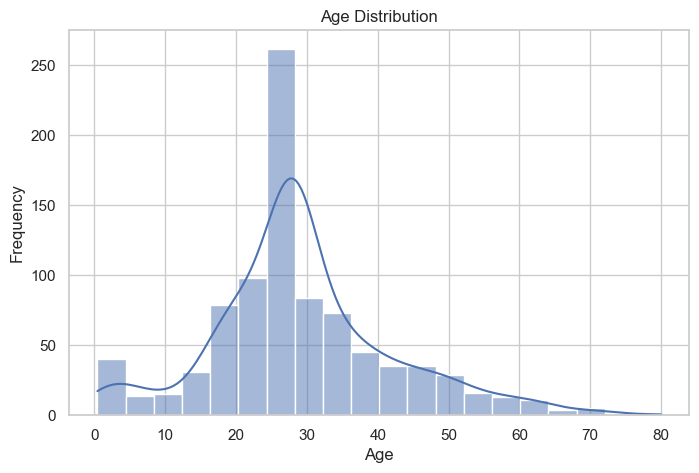

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(data['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

Interpretation:

Most passengers were young adults between 20–40 years old.

8. Passenger Class Distribution

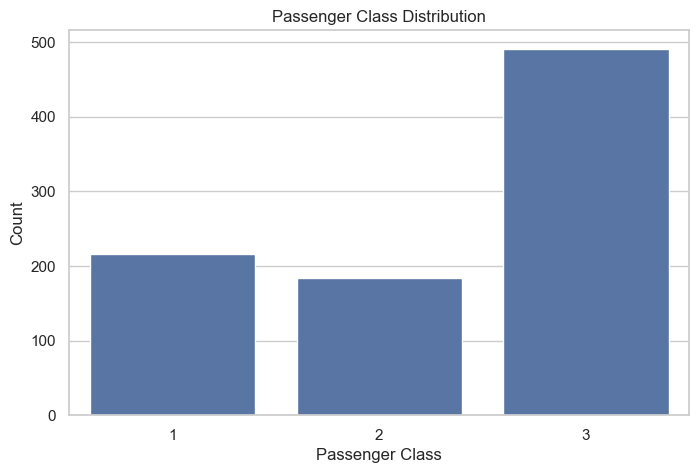

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x='Pclass', data=data)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.show()

Interpretation:

Most passengers belonged to Passenger Class 3.

9. Scatter Plot: Age vs Fare

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(data['Age'], data['Fare'], alpha=0.5)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

Interpretation:

No strong linear relationship is visible between Age and Fare.

10. Boxplot of Fare

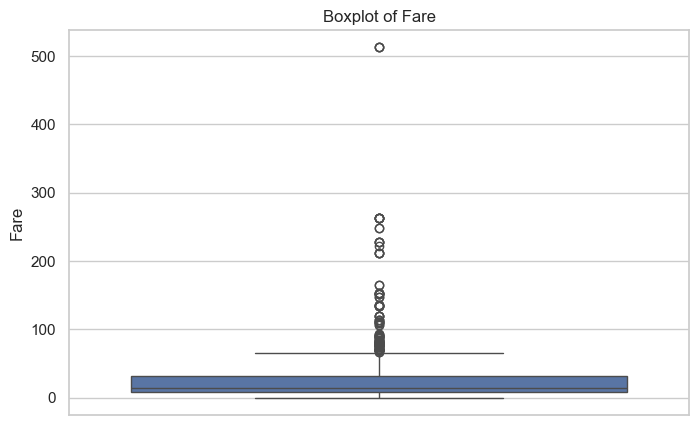

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(y=data['Fare'])

plt.title("Boxplot of Fare")

plt.show()

Interpretation:

The Fare column contains several outliers.

11. Survival Rate by Gender


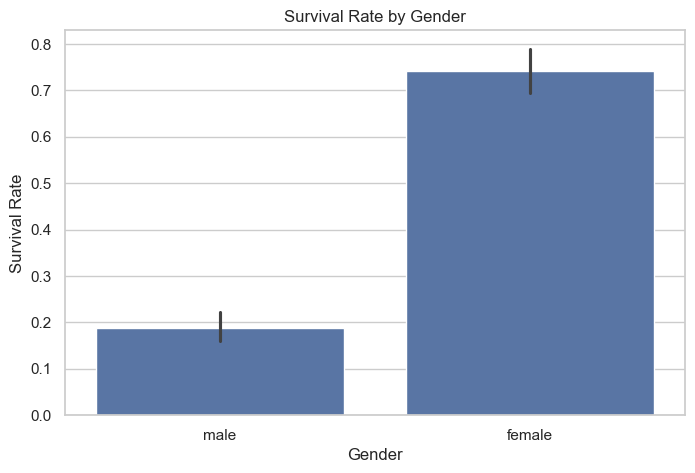

In [12]:
plt.figure(figsize=(8,5))

sns.barplot(x='Sex', y='Survived', data=data)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

Interpretation:

Female passengers had significantly higher survival rates than male passengers.

12. Survival Rate by Passenger Class


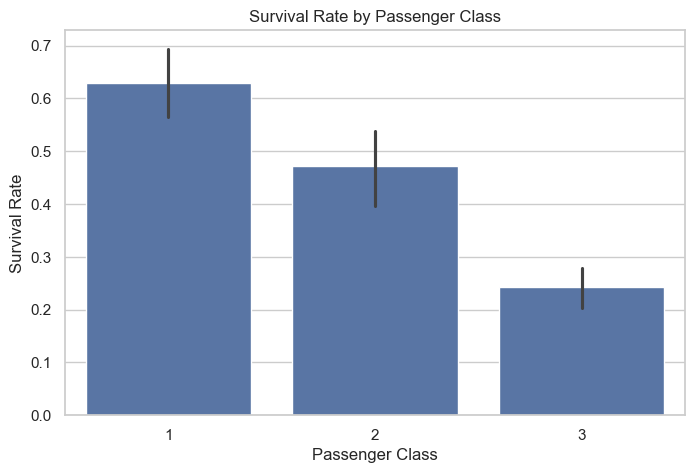

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(x='Pclass', y='Survived', data=data)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

Interpretation:

Passengers in higher classes had better survival probabilities.

13. Correlation Heatmap

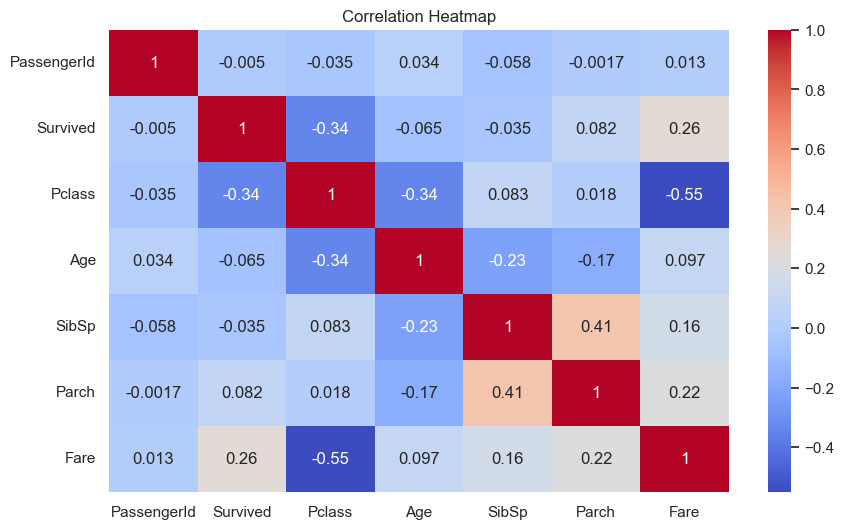

In [14]:
plt.figure(figsize=(10,6))

correlation = data.corr(numeric_only=True)

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

Interpretation:

Passenger Class and Fare show noticeable correlation.

14. Survival Count


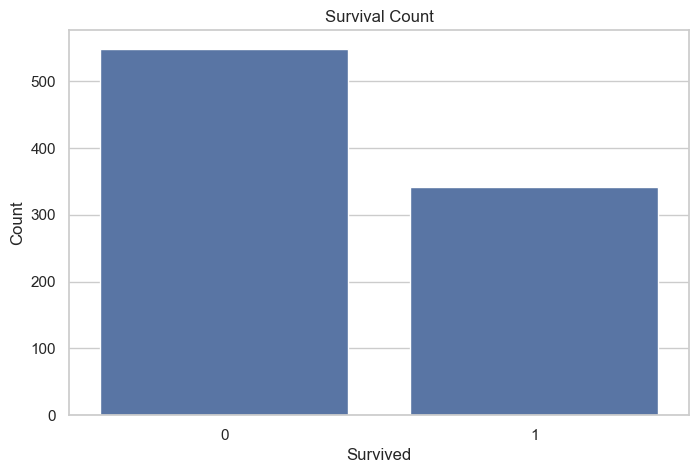

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(x='Survived', data=data)

plt.title("Survival Count")
plt.xlabel("Survived")
plt.ylabel("Count")

plt.show()

Interpretation:

More passengers did not survive compared to those who survived.

Conclusion:
    
1. Most passengers were young adults between 20–40 years old.
2. Passenger Class 3 had the highest number of passengers.
3. Female passengers showed significantly higher survival rates.
4. Higher-class passengers had better survival chances.
5. The Fare column contained several outliers.
6. Missing values were successfully handled during preprocessing.
7. Passenger Class, gender, and age influenced survival outcomes.
